In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter ,filtfilt,freqz
import scipy.signal

## Building a clean composite signal:

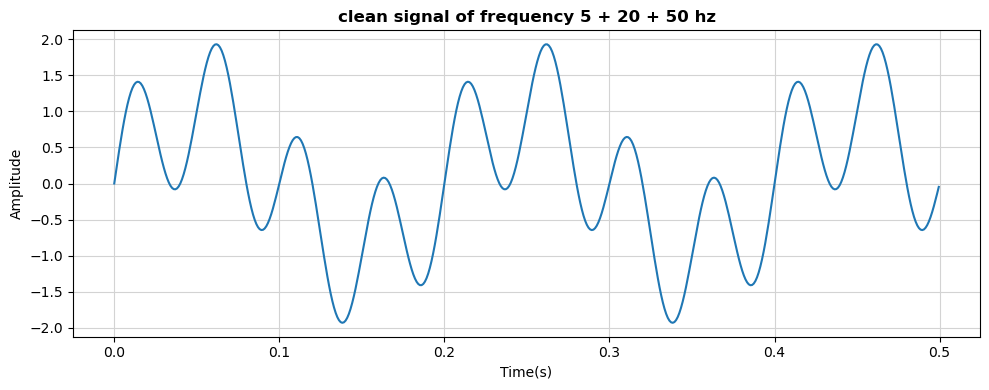

In [44]:
fs =1000            #sampling rate
t=np.linspace(0,1,fs)   #1 second

f1,f2,f3=5,20,50    # True signal with multiple source
y_clean= (np.sin(2*np.pi*f1*t)+
          np.sin(2*np.pi*f2*t))
plt.figure(figsize=(10,4))
plt.plot(t[:500],y_clean[:500])
plt.grid(color="lightgrey")
plt.title(f"clean signal of frequency {f1} + {f2} + {f3} hz",weight="bold")
plt.xlabel("Time(s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

## Adding noise :

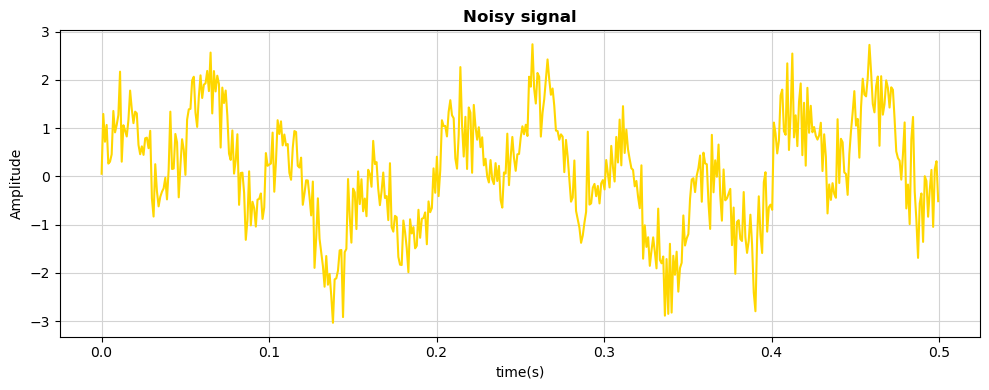

In [45]:
noise=np.random.normal(0,0.5,1000)  # noise 
y_noisy=y_clean + noise
plt.figure(figsize=(10,4))
plt.grid(True,color="lightgrey")
plt.plot(t[:500],y_noisy[:500],color="gold")
plt.xlabel("time(s)")
plt.ylabel("Amplitude")
plt.title("Noisy signal",weight="bold")
plt.tight_layout()
plt.show()


In [46]:
cutoff=30       # Hz — we want to keep only frequencies below 30 Hz
order=4         #filter order - higher -> sharpe cutoff 
b,a=butter(order,cutoff,btype='low',analog=False,fs=fs)
print(f"Filter designed : low-pass butterworth")
print(f"Cutoff:{cutoff} hz, order:{order}")
print(f"this will keep the frequency below 30 hz")
print(f"this will remove : 50hz component + noise above 30 hz")

Filter designed : low-pass butterworth
Cutoff:30 hz, order:4
this will keep the frequency below 30 hz
this will remove : 50hz component + noise above 30 hz


## visualize the filter's frequency response before applying:

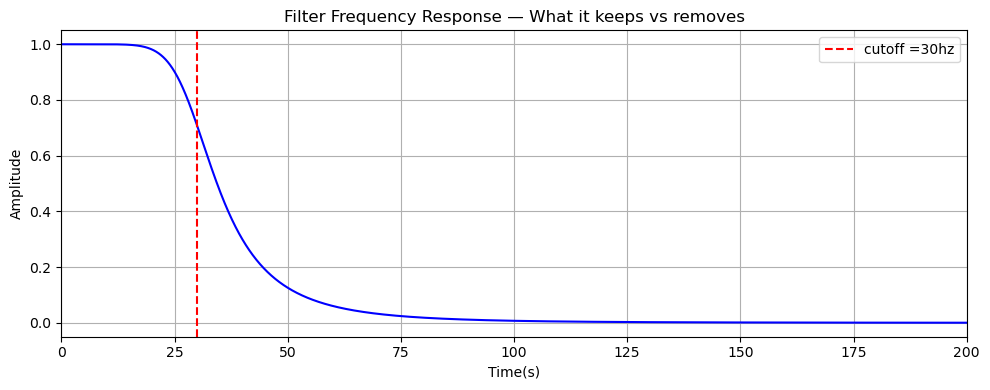

In [47]:
w,h= freqz(b,a,worN=8000,fs=fs)
plt.figure(figsize=(10,4))
plt.plot(w,np.abs(h),color="blue")
plt.grid(True)
plt.axvline(cutoff,color="red",linestyle="--",label=f'cutoff ={cutoff}hz')
plt.xlabel("Time(s)")
plt.ylabel("Amplitude")
plt.title("Filter Frequency Response — What it keeps vs removes")
plt.xlim(0,200)
plt.tight_layout()
plt.legend()
plt.show()

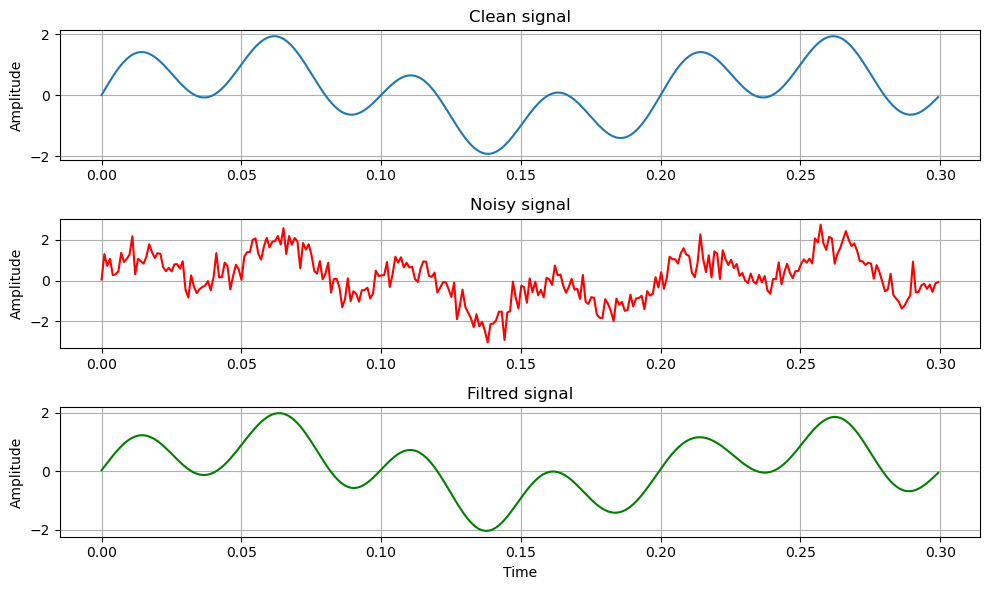

In [48]:
y_filter=filtfilt(b,a,y_noisy)
plt.figure(figsize=(10,6))

plt.subplot(3,1,1)
plt.plot(t[:300],y_clean[:300])
plt.title("Clean signal")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(t[:300],y_noisy[:300],color="red")
plt.title("Noisy signal")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(t[:300],y_filter[:300],color='green')
plt.title("Filtred signal")
plt.ylabel("Amplitude")
plt.xlabel("Time")
plt.grid(True)

plt.tight_layout()
plt.show()

## Measuring the improvement with SNR:

In [49]:
def snr(clean,noisy):
    noise=noisy-clean
    snr=10*np.log10(np.var(clean)/np.var(noise))
    return round(snr,2)
snr_before=snr(y_clean,y_noisy)
snr_after=snr(y_clean,y_filter)
print(f"SNR before filtering: {snr_before} db")
print(f"SNR after filtering :{snr_after} db")
print(f"Improvement : {round(snr_after-snr_before,2)} db")
print()
print("Higher SNR = cleaner signal")

SNR before filtering: 6.04 db
SNR after filtering :18.2 db
Improvement : 12.16 db

Higher SNR = cleaner signal


## Day 5 Log — filtfilt vs lfilter

lfilter() processes the signal in one direction (forward only).
This introduces phase delay — the filtered output is time-shifted
relative to the input. On a plot, the wave appears shifted right.

filtfilt() runs the filter forward then backward, cancelling the
phase delay completely. The output is zero-phase — perfectly
time-aligned with the original signal.

For ECG signals, zero-phase filtering is mandatory. Cardiologists
measure intervals between heartbeat features in milliseconds.
A phase shift would distort these intervals and could cause
misdiagnosis of arrhythmias.